In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('talk')

import gzip
import pickle

In [8]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Computer Modern Sans Serif"]})
plt.rcParams['text.latex.preamble'] = r'\usepackage{sansmath} \sansmath'

In [9]:
def load_pred(path):
    with gzip.open(path, "rb") as f:
        df = pickle.load(f)
    df["name"] = df["name"].str.removeprefix("/nfshome/sicolo/work/MLIP/dft_db/")
    df["name"] = df["name"].str.removesuffix("/OUTCAR##0")
    return df

test_data  = load_pred("test_pred.pckl.gzip")
train_data = load_pred("train_pred.pckl.gzip")

print(f"test:  {len(test_data)} structures")
print(f"train: {len(train_data)} structures")

test:  312 structures
train: 2814 structures


In [10]:
def structure_force_rms(row):
    f_true = np.array(row["forces"])
    f_pred = np.array(row["forces_pred"])
    return np.sqrt(np.mean((f_pred - f_true) ** 2))

for df in (test_data, train_data):
    df["force_rms"] = df.apply(structure_force_rms, axis=1)

pd.set_option("display.max_colwidth", None)
print("Test — worst force RMS:")
print(test_data.sort_values("force_rms", ascending=False)["name"].head(5).to_string())
print("\nTrain — worst force RMS:")
print(train_data.sort_values("force_rms", ascending=False)["name"].head(5).to_string())

Test — worst force RMS:
194                                                       surfaces/003/0ML/active_learning/iter_01/dft_39480
155    defective_structures/O_interstitials/LiNiO2_O3/1x1x1/moved_k1_atoms_2_sites_g2s1_ensembles/s1050_k000
209                                                    surfaces/NiO2/10-2_symm/active_learning/iter_01/25982
211                                                  surfaces/NiO2/10-5_symm/active_learning/iter_01/dft_015
154    defective_structures/O_interstitials/LiNiO2_O3/1x1x1/moved_k1_atoms_2_sites_g2s1_ensembles/s1040_k000

Train — worst force RMS:
1699                                               surfaces/003/0ML/s0960_xy_k000
1958                      surfaces/NiO2/10-5_symm/active_learning/iter_01/dft_010
961     defective_structures/stacking_faults/P3/active_learning/iter_01/dft_18117
976     defective_structures/stacking_faults/P3/active_learning/iter_01/dft_24057
1697                                               surfaces/003/0ML/s0950_xy_

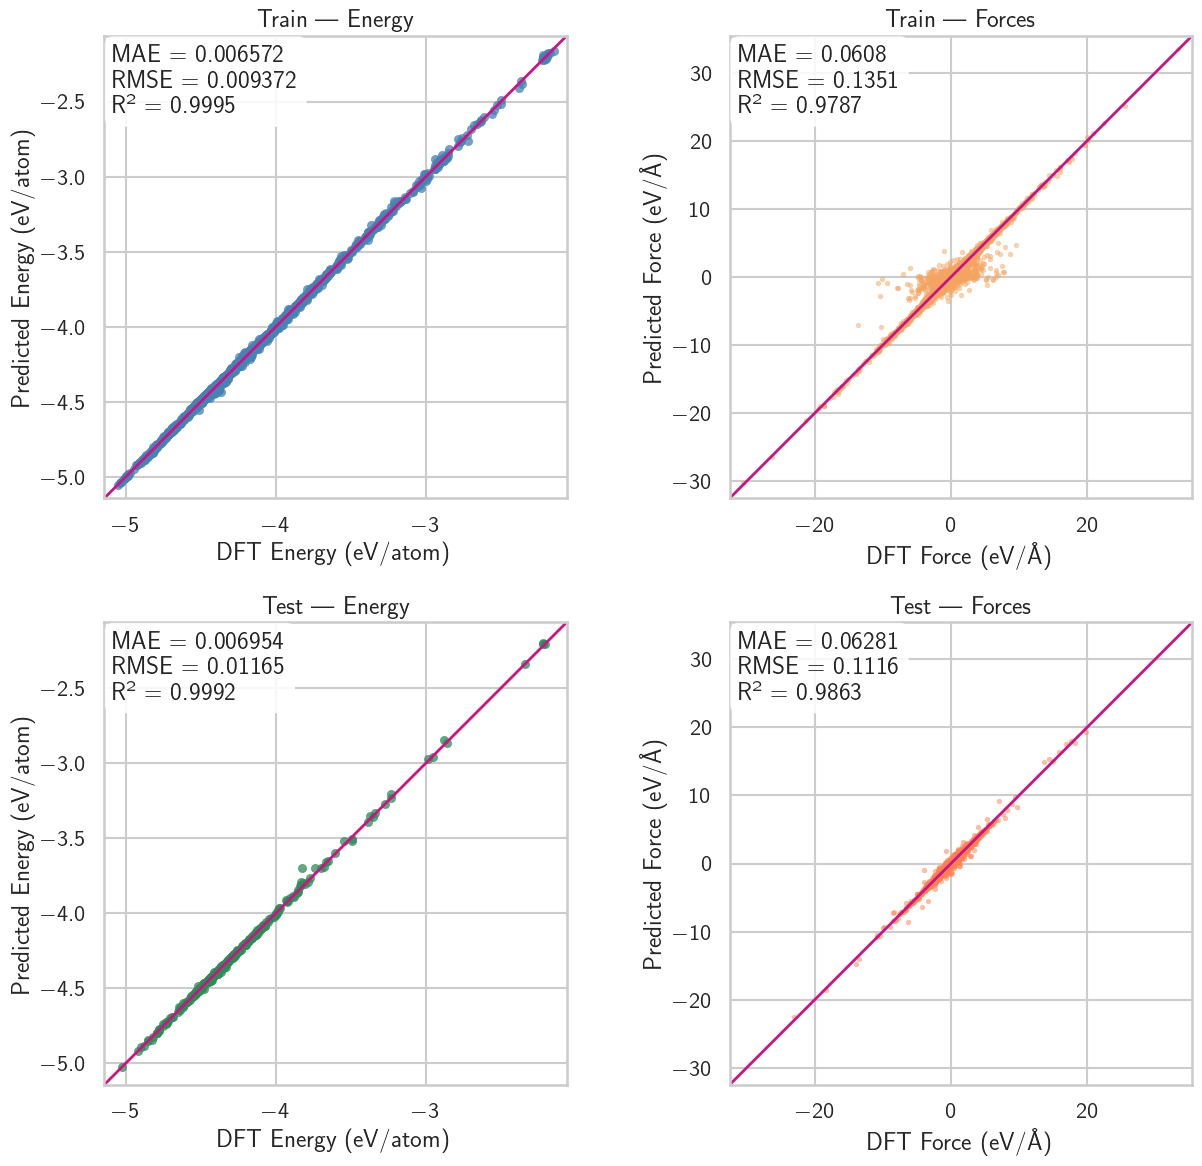

In [12]:
# ---------------------------
# Helpers
# ---------------------------
def regression_line(x, y):
    m, b = np.polyfit(x, y, 1)
    return m, b

def metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    err = y_pred - y_true
    mae  = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err ** 2))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
    return mae, rmse, r2

def padded_limits(x, y, pad_frac=0.03):
    x, y = np.asarray(x), np.asarray(y)
    mn = np.nanmin([x.min(), y.min()])
    mx = np.nanmax([x.max(), y.max()])
    span = mx - mn or 1.0
    pad = pad_frac * span
    return mn - pad, mx + pad

def set_parity_axes(ax, lims):
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_aspect("equal", adjustable="box")

def build_arrays(df):
    """Return (df_energy, df_forces) for one split."""
    fl_true = df["forces"].apply(lambda x: np.array(x).reshape(-1)).values
    fl_pred = df["forces_pred"].apply(lambda x: np.array(x).reshape(-1)).values
    forces_true = np.concatenate(fl_true)
    forces_pred = np.concatenate(fl_pred)
    names_f = np.concatenate([np.repeat(n, len(f)) for n, f in zip(df["name"], fl_true)])

    df_e = pd.DataFrame({
        "DFT":  (df["energy_corrected_per_atom"]).to_numpy(),
        "Pred": (df["energy_pred"] / df["NUMBER_OF_ATOMS"]).to_numpy(),
        "Name": df["name"].to_numpy(),
    })
    df_f = pd.DataFrame({
        "DFT":  forces_true,
        "Pred": forces_pred,
        "Name": names_f,
    })
    return df_e, df_f

# ---------------------------
# Build arrays for both splits
# ---------------------------
test_e,  test_f  = build_arrays(test_data)
train_e, train_f = build_arrays(train_data)

# Shared parity limits (same scale across train/test for fair comparison)
e_lims = padded_limits(
    np.concatenate([test_e["DFT"],  train_e["DFT"]]),
    np.concatenate([test_e["Pred"], train_e["Pred"]]),
)
f_lims = padded_limits(
    np.concatenate([test_f["DFT"],  train_f["DFT"]]),
    np.concatenate([test_f["Pred"], train_f["Pred"]]),
)

# ---------------------------
# Plot settings
# ---------------------------
sns.set_style("whitegrid")
ENERGY_COLORS = {"train": "steelblue",   "test": "seagreen"}
FORCE_COLORS  = {"train": "sandybrown",  "test": "coral"}
PARITY_COLOR  = "mediumvioletred"
SHOW_BEST_FIT = False

datasets = [
    ("train", train_e, train_f, ENERGY_COLORS["train"], FORCE_COLORS["train"]),
    ("test",  test_e,  test_f,  ENERGY_COLORS["test"],  FORCE_COLORS["test"]),
]

# ---------------------------
# Figure: 2 rows (train, test) × 2 cols (energy, forces)
# ---------------------------
fig, axes = plt.subplots(2, 2, figsize=(13, 12))

for row_idx, (split, df_e, df_f, ec, fc) in enumerate(datasets):
    # -------- ENERGY --------
    ax = axes[row_idx, 0]
    e_mae, e_rmse, e_r2 = metrics(df_e["DFT"], df_e["Pred"])

    sns.scatterplot(data=df_e, x="DFT", y="Pred", ax=ax,
                    s=35, alpha=0.75, color=ec, edgecolor=None)
    ax.plot(e_lims, e_lims, color=PARITY_COLOR, linewidth=2)

    if SHOW_BEST_FIT:
        m, b = regression_line(df_e["DFT"], df_e["Pred"])
        xs = np.array(e_lims)
        ax.plot(xs, m*xs + b, linestyle="--", linewidth=2)

    set_parity_axes(ax, e_lims)
    ax.set_title(f"{split.capitalize()} — Energy")
    ax.set_xlabel("DFT Energy (eV/atom)")
    ax.set_ylabel("Predicted Energy (eV/atom)")
    ax.text(0.02, 0.98,
            f"MAE  = {e_mae:.4g}\nRMSE = {e_rmse:.4g}\nR²   = {e_r2:.4g}",
            transform=ax.transAxes, va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85))

    # -------- FORCES --------
    ax = axes[row_idx, 1]
    f_mae, f_rmse, f_r2 = metrics(df_f["DFT"], df_f["Pred"])

    sns.scatterplot(data=df_f, x="DFT", y="Pred", ax=ax,
                    s=12, alpha=0.5, color=fc, edgecolor=None)
    ax.plot(f_lims, f_lims, color=PARITY_COLOR, linewidth=2)

    if SHOW_BEST_FIT:
        m, b = regression_line(df_f["DFT"], df_f["Pred"])
        xs = np.array(f_lims)
        ax.plot(xs, m*xs + b, linestyle="--", linewidth=2)

    set_parity_axes(ax, f_lims)
    ax.set_title(f"{split.capitalize()} — Forces")
    ax.set_xlabel("DFT Force (eV/Å)")
    ax.set_ylabel("Predicted Force (eV/Å)")
    ax.text(0.02, 0.98,
            f"MAE  = {f_mae:.4g}\nRMSE = {f_rmse:.4g}\nR²   = {f_r2:.4g}",
            transform=ax.transAxes, va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85))

plt.tight_layout()
# plt.savefig("parity_train_test.png", bbox_inches="tight", dpi=200)
plt.show()